In [ ]:
# -----------------------------
# Load Dataset
# -----------------------------
import pandas as pd
url = "https://firms.modaps.eosdis.nasa.gov/data/active_fire/modis-c6.1/csv/MODIS_C6_1_Global_7d.csv"

df = pd.read_csv(url)

print(df.head())
print(df.columns)

   latitude  longitude  brightness  scan  track    acq_date  acq_time  \
0 -20.23947  -40.23537      318.96  2.15   1.43  2026-04-28        11   
1 -20.24304  -40.25535      304.08  2.15   1.42  2026-04-28        11   
2 -17.57314  -47.82038      304.68  1.00   1.00  2026-04-28        13   
3 -17.09316  -51.04935      302.59  1.33   1.14  2026-04-28        13   
4 -13.40701  -45.32943      316.41  1.25   1.11  2026-04-28        13   

  satellite  confidence version  bright_t31    frp daynight  
0         T          98  6.1NRT      294.46  44.60        N  
1         T          57  6.1NRT      294.06  10.55        N  
2         T          61  6.1NRT      291.73   6.52        N  
3         T          50  6.1NRT      287.89   7.93        N  
4         T          93  6.1NRT      291.18  20.16        N  
Index(['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'confidence', 'version', 'bright_t31', 'frp',
       'daynight'],
      dtype='str

In [ ]:
# -----------------------------
# Imports
# -----------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GroupShuffleSplit

try:
    from xgboost import XGBClassifier
except Exception as e:
    raise ImportError(
        "xgboost is not installed in this kernel. Run: %pip install xgboost"
    ) from e

In [4]:
# -----------------------------
# 1) Basic checks and cleanup
# -----------------------------
assert 'df' in globals(), "DataFrame df not found in current notebook kernel."

data = df.copy()

# Standardize column names for easier matching
orig_cols = data.columns.tolist()
data.columns = [c.strip().lower().replace(' ', '_') for c in data.columns]

# Convert likely numeric columns that may be read as object
for c in data.columns:
    if data[c].dtype == 'object':
        data[c] = pd.to_numeric(data[c], errors='ignore')

print(f"Rows: {len(data):,} | Columns: {len(data.columns)}")

Rows: 44,056 | Columns: 13


In [5]:
# -----------------------------
# 2) Identify coordinate columns
# -----------------------------
lat_candidates = [c for c in data.columns if c in ['lat', 'latitude'] or 'lat' == c]
lon_candidates = [c for c in data.columns if c in ['lon', 'long', 'longitude', 'lng'] or c == 'lon']

if not lat_candidates:
    lat_candidates = [c for c in data.columns if 'lat' in c]
if not lon_candidates:
    lon_candidates = [c for c in data.columns if any(k in c for k in ['lon', 'long', 'lng'])]

lat_col = lat_candidates[0] if lat_candidates else None
lon_col = lon_candidates[0] if lon_candidates else None

print("Detected latitude column:", lat_col)
print("Detected longitude column:", lon_col)

Detected latitude column: latitude
Detected longitude column: longitude


In [6]:
# -----------------------------
# 3) Build/locate target risk column (3 classes)
# -----------------------------
# Priority:
# - existing multiclass risk-like column
# - existing fire index column binned into 3 quantile levels
risk_like_cols = [
    c for c in data.columns
    if any(k in c for k in ['risk', 'class', 'label', 'fire_risk'])
]

fire_index_candidates = [
    c for c in data.columns
    if any(k in c for k in ['fwi', 'fire_weather_index', 'frp', 'brightness', 'drought', 'ndvi', 'vi'])
]

y_col = None

# Try existing label column first
for c in risk_like_cols:
    nuniq = data[c].nunique(dropna=True)
    if 2 <= nuniq <= 6:
        y_col = c
        break

# Otherwise create from a continuous fire-index-like column
if y_col is None:
    cont_candidates = [c for c in fire_index_candidates if pd.api.types.is_numeric_dtype(data[c])]
    if not cont_candidates:
        numeric_cols_all = data.select_dtypes(include=[np.number]).columns.tolist()
        if lat_col in numeric_cols_all:
            numeric_cols_all.remove(lat_col)
        if lon_col in numeric_cols_all:
            numeric_cols_all.remove(lon_col)
        cont_candidates = numeric_cols_all

    if not cont_candidates:
        raise ValueError("Could not infer a target variable. Please provide a risk/class label column.")

    base_target = cont_candidates[0]
    q = data[base_target].quantile([0.33, 0.66]).values

    def make_risk(v):
        if pd.isna(v):
            return np.nan
        if v <= q[0]:
            return 'low'
        elif v <= q[1]:
            return 'medium'
        return 'high'

    y_col = 'risk_level'
    data[y_col] = data[base_target].apply(make_risk)
    print(f"Created target '{y_col}' from continuous column '{base_target}'.")
else:
    print(f"Using existing target column: '{y_col}'")

# Normalize label names to low/medium/high where possible
if data[y_col].dtype == 'object':
    data[y_col] = data[y_col].astype(str).str.strip().str.lower()
    mapping = {
        'not_fire': 'low',
        'no_fire': 'low',
        'fire': 'high',
        'moderate': 'medium',
        'med': 'medium'
    }
    data[y_col] = data[y_col].replace(mapping)

# Keep only rows with valid target
data = data.dropna(subset=[y_col]).copy()

# Force 3-level classes when possible
if data[y_col].nunique() > 3 and pd.api.types.is_numeric_dtype(data[y_col]):
    q = data[y_col].quantile([0.33, 0.66]).values
    data[y_col] = pd.cut(
        data[y_col],
        bins=[-np.inf, q[0], q[1], np.inf],
        labels=['low', 'medium', 'high']
    )

print("Target class distribution:")
print(data[y_col].value_counts(dropna=False))

Created target 'risk_level' from continuous column 'brightness'.
Target class distribution:
risk_level
high      14965
low       14546
medium    14545
Name: count, dtype: int64


In [7]:
# -----------------------------
# 4) Feature selection
# -----------------------------
# Use meteorological + vegetation + useful numeric/categorical predictors, excluding explicit leakage columns
exclude_cols = {y_col}

# If target was created from a source column, avoid leaking it directly
if 'base_target' in locals() and base_target in data.columns:
    exclude_cols.add(base_target)

# Common columns to exclude from predictors
for c in data.columns:
    if any(k in c for k in ['date', 'time', 'acq_time', 'acq_date']):
        exclude_cols.add(c)

feature_cols = [c for c in data.columns if c not in exclude_cols]

X = data[feature_cols].copy()
y = data[y_col].copy()

# Encode target labels
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
print("Encoded classes:", class_names)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ],
    remainder='drop'
)

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=len(class_names),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

clf = Pipeline([
    ('prep', preprocessor),
    ('model', xgb_model)
])

Encoded classes: ['high', 'low', 'medium']


In [8]:
# -----------------------------
# 5) Spatial split for evaluation
# -----------------------------
if lat_col and lon_col and lat_col in data.columns and lon_col in data.columns:
    # Create coarse spatial blocks; hold out unseen blocks for testing
    lat_bin = np.floor(data[lat_col].astype(float) * 2) / 2.0   # 0.5 degree bins
    lon_bin = np.floor(data[lon_col].astype(float) * 2) / 2.0
    groups = lat_bin.astype(str) + "_" + lon_bin.astype(str)

    gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    train_idx, test_idx = next(gss.split(X, y_enc, groups=groups))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]
    test_geo = data.iloc[test_idx].copy()

    split_mode = "Spatial Group Split (recommended)"
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
    )
    test_geo = data.loc[X_test.index].copy()
    split_mode = "Random Split (no lat/lon found)"

print("Split mode:", split_mode)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Split mode: Spatial Group Split (recommended)
Train: 32,493 | Test: 11,563


In [9]:
# -----------------------------
# 6) Train and evaluate
# -----------------------------
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("\n=== XGBoost Evaluation ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Macro F1:  {macro_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=[f"True_{c}" for c in class_names], columns=[f"Pred_{c}" for c in class_names])
print("Confusion Matrix:")
display(cm_df)


=== XGBoost Evaluation ===
Accuracy:  0.9224
Macro F1:  0.9223

Classification Report:
              precision    recall  f1-score   support

        high     0.9571    0.9435    0.9503      4000
         low     0.9306    0.9345    0.9325      3728
      medium     0.8793    0.8887    0.8839      3835

    accuracy                         0.9224     11563
   macro avg     0.9223    0.9222    0.9223     11563
weighted avg     0.9227    0.9224    0.9226     11563

Confusion Matrix:


,Pred_high,Pred_low,Pred_medium
True_high,3774,2,224
True_low,0,3484,244
True_medium,169,258,3408


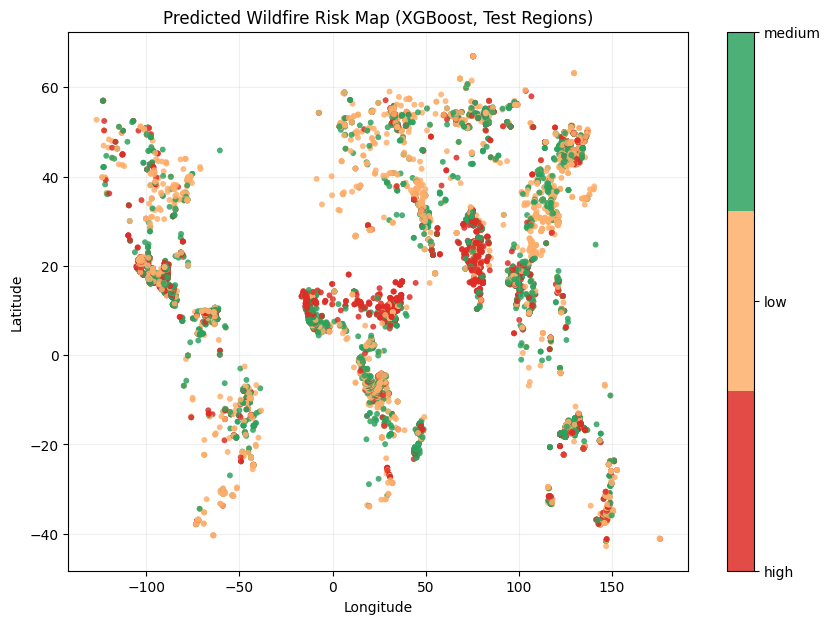


Spatial accuracy summary (by 0.5° grid):
count    1869.0000
mean        0.9168
std         0.2072
min         0.0000
25%         0.9474
50%         1.0000
75%         1.0000
max         1.0000
Name: cell_accuracy, dtype: float64


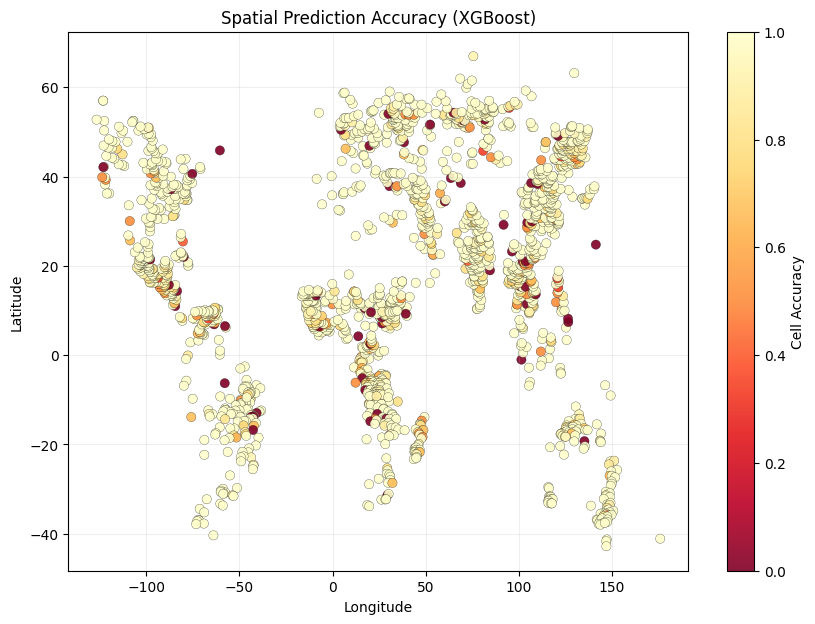

In [11]:
# -----------------------------
# 7) Spatial risk map visualization (predicted on test set)
# -----------------------------
if lat_col and lon_col and lat_col in test_geo.columns and lon_col in test_geo.columns:
    test_geo['y_true_label'] = le.inverse_transform(y_test)
    test_geo['y_pred_label'] = le.inverse_transform(y_pred)

    # numeric index for color mapping
    label_to_num = {lbl: i for i, lbl in enumerate(class_names)}
    test_geo['pred_num'] = test_geo['y_pred_label'].map(label_to_num)

    cmap = ListedColormap(['#de2d26', '#fdae6b', '#2ca25f'][:len(class_names)])

    plt.figure(figsize=(10, 7))
    sc = plt.scatter(
        test_geo[lon_col],
        test_geo[lat_col],
        c=test_geo['pred_num'],
        cmap=cmap,
        s=18,
        alpha=0.85,
        edgecolors='none'
    )

    cbar = plt.colorbar(sc, ticks=range(len(class_names)))
    cbar.ax.set_yticklabels(class_names)

    plt.title('Predicted Wildfire Risk Map (XGBoost, Test Regions)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(alpha=0.2)
    plt.show()

    # Spatial accuracy by coarse grid cell
    cell_lat = np.floor(test_geo[lat_col].astype(float) * 2) / 2.0
    cell_lon = np.floor(test_geo[lon_col].astype(float) * 2) / 2.0
    test_geo['grid_cell'] = cell_lat.astype(str) + '_' + cell_lon.astype(str)
    test_geo['correct'] = (test_geo['y_true_label'] == test_geo['y_pred_label']).astype(int)

    spatial_acc = test_geo.groupby('grid_cell', as_index=False)['correct'].mean().rename(columns={'correct': 'cell_accuracy'})

    print("\nSpatial accuracy summary (by 0.5° grid):")
    print(spatial_acc['cell_accuracy'].describe().round(4))

    # Plot cell-wise accuracy points
    cell_centers = test_geo.groupby('grid_cell', as_index=False)[[lat_col, lon_col]].mean()
    spatial_plot = cell_centers.merge(spatial_acc, on='grid_cell', how='inner')

    plt.figure(figsize=(10, 7))
    sc2 = plt.scatter(
        spatial_plot[lon_col],
        spatial_plot[lat_col],
        c=spatial_plot['cell_accuracy'],
        cmap='YlOrRd_r',
        s=45,
        alpha=0.9,
        edgecolors='k',
        linewidths=0.2
    )
    plt.colorbar(sc2, label='Cell Accuracy')
    plt.title('Spatial Prediction Accuracy (XGBoost)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(alpha=0.2)
    plt.show()
else:
    print("No latitude/longitude columns detected, so spatial risk maps were skipped.")

In [12]:
# -----------------------------
# 8) Optional: risk prediction for full dataset
# -----------------------------
full_pred = clf.predict(X)
data['predicted_risk_level'] = le.inverse_transform(full_pred)
print("\nSample predictions:")
display(data[[y_col, 'predicted_risk_level']].head(10))


Sample predictions:


,risk_level,predicted_risk_level
0,medium,medium
1,low,low
2,low,low
3,low,low
4,medium,medium
5,low,low
6,low,low
7,medium,medium
8,high,high
9,high,high


In [13]:
correct_predictions = (y_test == y_pred).sum()
total_risk_cases = len(y_test)

print("Correct predictions:", correct_predictions)
print("Total risk cases:", total_risk_cases)
print("Accuracy:", correct_predictions / total_risk_cases)

Correct predictions: 10666
Total risk cases: 11563
Accuracy: 0.9224249762172446


In [14]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("Total correct predictions:", cm.trace())
print("Total cases:", cm.sum())

[[3774    2  224]
 [   0 3484  244]
 [ 169  258 3408]]
Total correct predictions: 10666
Total cases: 11563


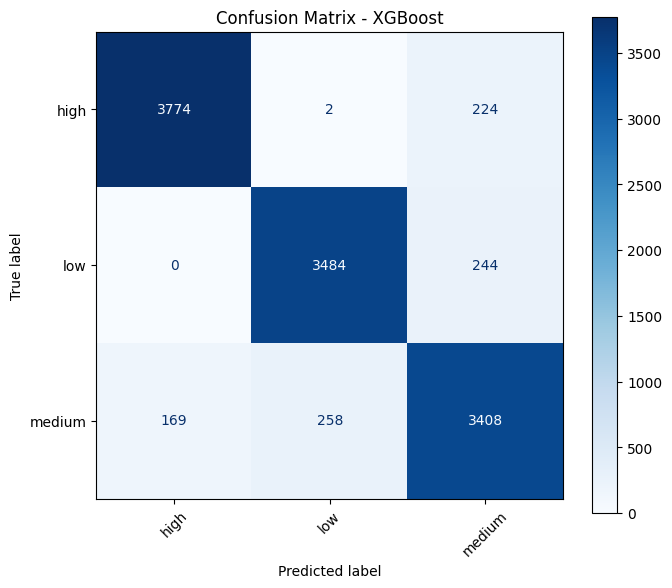

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - XGBoost')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()